<a href="https://colab.research.google.com/github/Notmefrfr/Data_analytic/blob/Toyota-Used-Cars/datminingToyotaUsedCar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Library

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


Load Dataset

In [ ]:
df = pd.read_csv('/content/toyota.csv')
print(df.head())

   model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   GT86  2016  16000       Manual    24089   Petrol  265  36.2         2.0
1   GT86  2017  15995       Manual    18615   Petrol  145  36.2         2.0
2   GT86  2015  13998       Manual    27469   Petrol  265  36.2         2.0
3   GT86  2017  18998       Manual    14736   Petrol  150  36.2         2.0
4   GT86  2017  17498       Manual    36284   Petrol  145  36.2         2.0


Heatmap

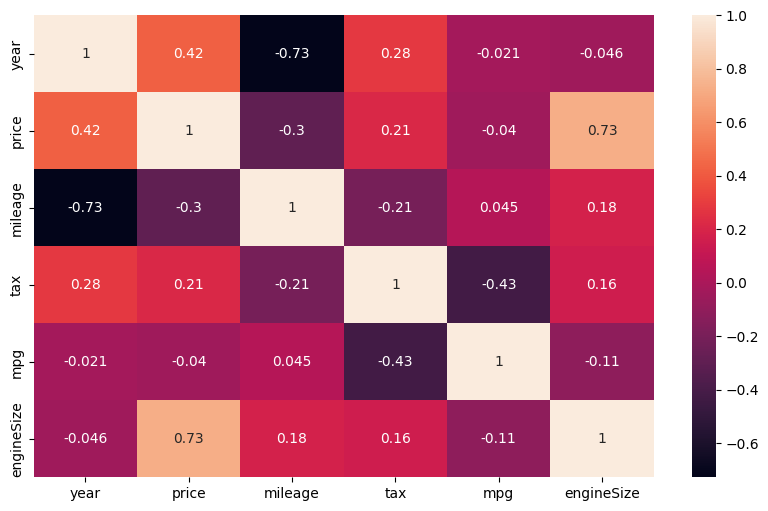

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()


From the heatmap, engineSize has the strongest correlation with price (r = 0.73). This suggests that engine size is the most influential numerical variable for predicting Toyota car prices. Newer year also increases price (r = 0.42), while higher mileage tends to decrease price (r = -0.30). Fuel type and transmission also show notable relationships with price.

Create Price Category (Low / Mid / High)

In [ ]:
df['price_category'] = pd.qcut(df['price'], q=3, labels=['Low', 'Mid', 'High'])
print(df['price_category'].value_counts())

price_category
Mid     2253
Low     2252
High    2233
Name: count, dtype: int64


Encode Categorical Columns

In [ ]:
cat_cols = ['model', 'transmission', 'fuelType', 'price_category']
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

Train-Test Split

In [ ]:
X = df.drop(['price', 'price_category'], axis=1)
y = df['price_category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Scalling

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train 5 model

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

accuracy_results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred

    acc = accuracy_score(y_test, pred)
    accuracy_results[name] = acc

    print("=================================================")
    print(name)
    print("Accuracy:", acc)
    print(classification_report(y_test, pred))

Logistic Regression
Accuracy: 0.8078635014836796
              precision    recall  f1-score   support

           0       0.87      0.81      0.84       467
           1       0.85      0.87      0.86       434
           2       0.71      0.75      0.73       447

    accuracy                           0.81      1348
   macro avg       0.81      0.81      0.81      1348
weighted avg       0.81      0.81      0.81      1348

KNN
Accuracy: 0.8805637982195845
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       467
           1       0.90      0.90      0.90       434
           2       0.82      0.81      0.82       447

    accuracy                           0.88      1348
   macro avg       0.88      0.88      0.88      1348
weighted avg       0.88      0.88      0.88      1348

Decision Tree
Accuracy: 0.8686943620178041
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       467
    

Compare Model Accuracy


MODEL COMPARISON:
                     Accuracy
Logistic Regression  0.807864
KNN                  0.880564
Decision Tree        0.868694
Random Forest        0.890208
SVM                  0.878338


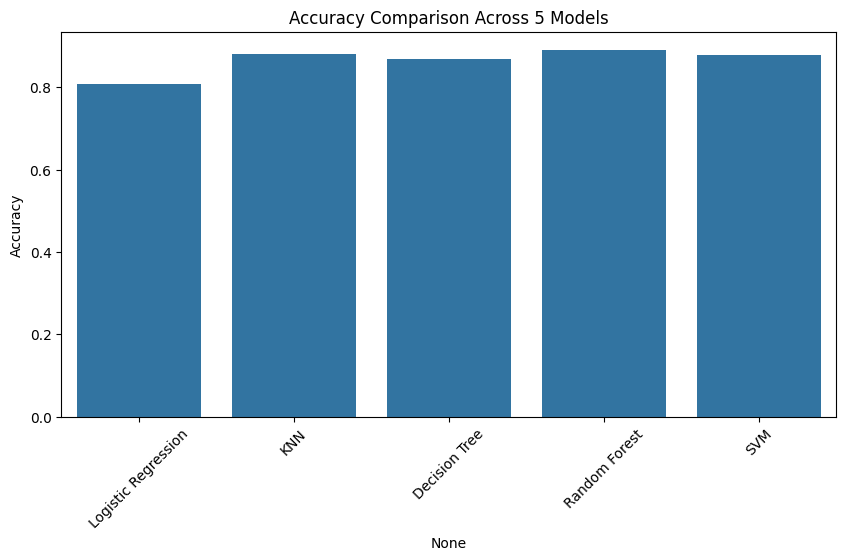

In [ ]:
acc_df = pd.DataFrame.from_dict(accuracy_results, orient='index', columns=['Accuracy'])
print("\nMODEL COMPARISON:")
print(acc_df)

plt.figure(figsize=(10,5))
sns.barplot(x=acc_df.index, y=acc_df['Accuracy'])
plt.xticks(rotation=45)
plt.title("Accuracy Comparison Across 5 Models")
plt.show()

Feature Importance from Random Forest

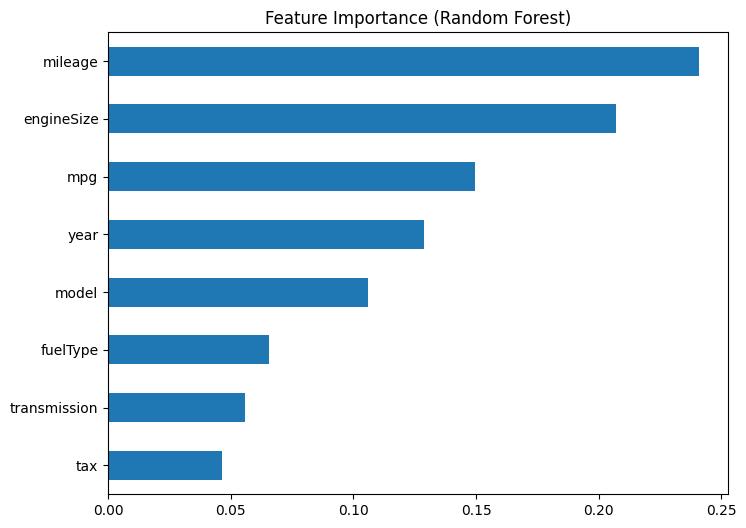

In [ ]:
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot.barh(figsize=(8,6))
plt.title("Feature Importance (Random Forest)")
plt.show()

Random Forest feature importance shows that mileage is the most influential predictor of Toyota vehicle price categories. This suggests that usage level (reflected by mileage) plays a greater role in determining price than manufacturing year, model type, or transmission. Cars with lower mileage consistently fall into higher price categories, while higher mileage strongly correlates with lower price categories.



> we use Random Forest because its the highest Accuracy Across 5 model



Bellow is the other Model use in the train

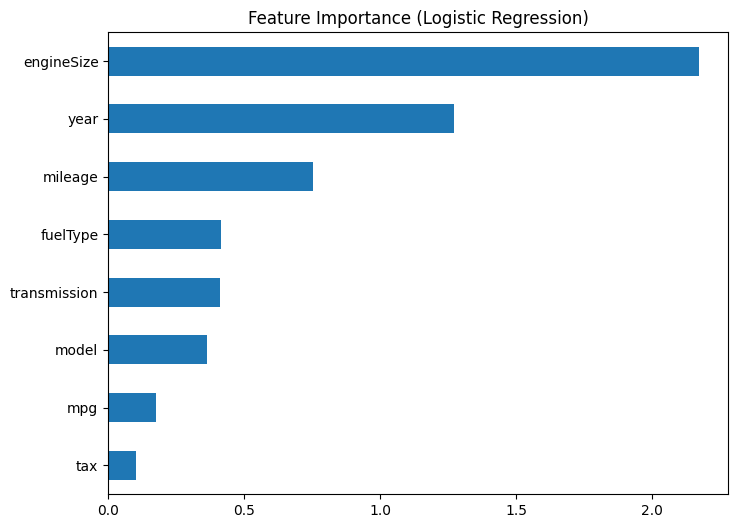

In [ ]:
lr = models["Logistic Regression"]
importance = np.abs(lr.coef_).mean(axis=0)
importances = pd.Series(importance, index=X.columns)

importances.sort_values(ascending=True).plot.barh(figsize=(8,6))
plt.title("Feature Importance (Logistic Regression)")
plt.show()


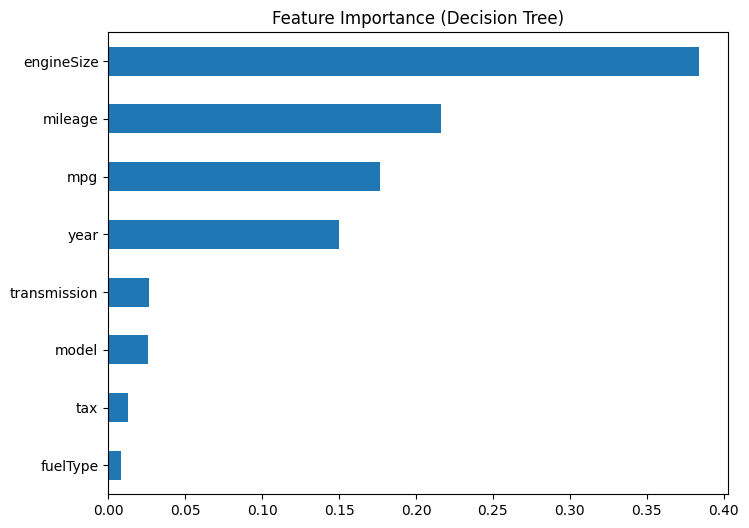

In [ ]:
dt = models["Decision Tree"]
importances = pd.Series(dt.feature_importances_, index=X.columns)

importances.sort_values(ascending=True).plot.barh(figsize=(8,6))
plt.title("Feature Importance (Decision Tree)")
plt.show()


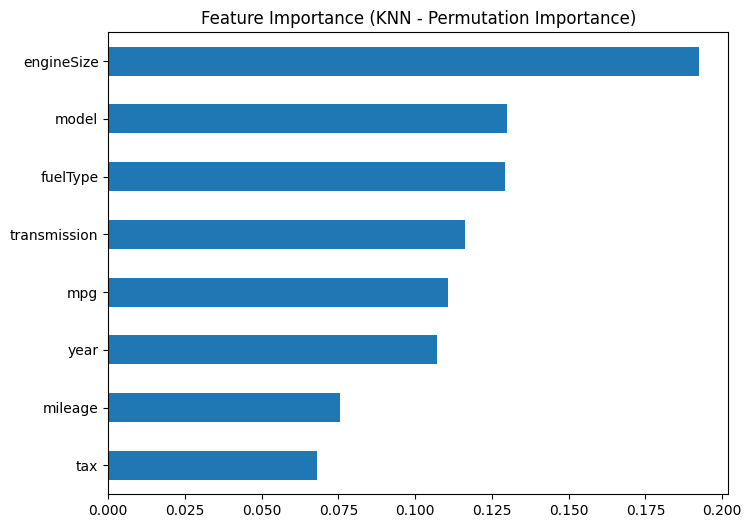

In [ ]:
from sklearn.inspection import permutation_importance

knn = models["KNN"]
perm = permutation_importance(knn, X_test, y_test, n_repeats=10, random_state=42)

importances = pd.Series(perm.importances_mean, index=X.columns)

importances.sort_values(ascending=True).plot.barh(figsize=(8,6))
plt.title("Feature Importance (KNN - Permutation Importance)")
plt.show()


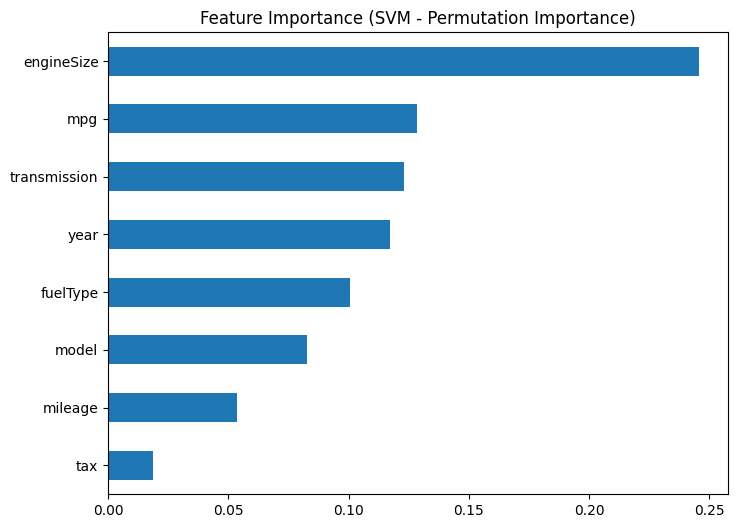

In [ ]:
svm = models["SVM"]
perm = permutation_importance(svm, X_test, y_test, n_repeats=10, random_state=42)

importances = pd.Series(perm.importances_mean, index=X.columns)

importances.sort_values(ascending=True).plot.barh(figsize=(8,6))
plt.title("Feature Importance (SVM - Permutation Importance)")
plt.show()
